# Задание 2 — Оптимизаторы и шедулеры

**Баллов:** 5

- Используя код практики или PyTorch, реализовать **3 оптимизатора** (например, Nesterov, Adam, RMSProp).
- Реализовать **любые 2 шедулера** (например, StepLR и ExponentialLR). Проверить реализованное на сгенерированной регрессии.
- Показать **графики изменения LR** в течение 100 эпох.
- **Доказать корректность** реализации оптимизаторов.

In [1]:
import math
import copy
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LRScheduler
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
EPOCHS = 100
LR = 1e-2
BATCH_SIZE = 64
NUM_SAMPLES = 512

## Оптимизаторы (ручная реализация)

In [3]:
class NesterovSGD(optim.Optimizer):
    def __init__(self, params, lr, momentum=0.9):
        if lr <= 0.0 or momentum < 0.0:
            raise ValueError("lr must be > 0 and momentum >= 0")
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            mu = group['momentum']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if 'momentum_buffer' not in state:
                    buf = g.clone().detach()
                    state['momentum_buffer'] = buf
                else:
                    buf = state['momentum_buffer']
                    buf.mul_(mu).add_(g)
                update = g.add(buf, alpha=mu)
                p.add_(update, alpha=-lr)

In [4]:
class Adam(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        if lr <= 0.0 or eps < 0.0:
            raise ValueError("lr must be > 0 and eps >= 0")
        if not (0.0 <= betas[0] < 1.0 and 0.0 <= betas[1] < 1.0):
            raise ValueError("betas must be in [0, 1)")
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2 = group['betas']
            eps = group['eps']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)
                m, v = state['exp_avg'], state['exp_avg_sq']
                state['step'] += 1
                t = state['step']
                m.mul_(beta1).add_(g, alpha=1.0 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1.0 - beta2)
                bc1 = 1.0 - beta1 ** t
                bc2 = 1.0 - beta2 ** t
                step_size = lr / bc1
                denom = v.sqrt().div(math.sqrt(bc2)).add_(eps)
                p.addcdiv_(m, denom, value=-step_size)

In [5]:
class RMSProp(optim.Optimizer):
    def __init__(self, params, lr=1e-2, alpha=0.99, eps=1e-8):
        if lr <= 0.0 or eps < 0.0:
            raise ValueError("lr must be > 0 and eps >= 0")
        if not 0.0 <= alpha < 1.0:
            raise ValueError("alpha must be in [0, 1)")
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            alpha = group['alpha']
            eps = group['eps']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p)
                sq = state['square_avg']
                sq.mul_(alpha).addcmul_(g, g, value=1.0 - alpha)
                avg = sq.sqrt().add_(eps)
                p.addcdiv_(g, avg, value=-lr)

## Доказательство корректности оптимизаторов

In [8]:
def _make_fixture(seed=SEED, in_dim=4, out_dim=2, n=8):
    torch.manual_seed(seed)
    model = nn.Linear(in_dim, out_dim)
    x = torch.randn(n, in_dim)
    y = torch.randn(n, out_dim)
    return model, x, y


def _compare(custom_opt_cls, ref_opt_cls, opt_kwargs, n_steps=20, atol=1e-6):
    model_c, x, y = _make_fixture()
    model_r = copy.deepcopy(model_c)
    opt_c = custom_opt_cls(model_c.parameters(), **opt_kwargs)
    opt_r = ref_opt_cls(model_r.parameters(), **opt_kwargs)
    loss_fn = nn.MSELoss()

    for step in range(1, n_steps + 1):
        opt_c.zero_grad()
        loss_c = loss_fn(model_c(x), y)
        loss_c.backward()
        opt_c.step()
        opt_r.zero_grad()
        loss_r = loss_fn(model_r(x), y)
        loss_r.backward()
        opt_r.step()
        for pc, pr in zip(model_c.parameters(), model_r.parameters()):
            assert torch.allclose(pc, pr, atol=atol), (
                f"Mismatch at step {step}: max |Δ| = {(pc - pr).abs().max().item():.3e}"
            )
    return True


_compare(
    custom_opt_cls=NesterovSGD,
    ref_opt_cls=lambda params, **kw: optim.SGD(params, momentum=kw['momentum'], nesterov=True, dampening=0, lr=kw['lr']),
    opt_kwargs=dict(lr=1e-2, momentum=0.9),
)

_compare(
    custom_opt_cls=Adam,
    ref_opt_cls=optim.Adam,
    opt_kwargs=dict(lr=1e-3, betas=(0.9, 0.999), eps=1e-8),
)

_compare(
    custom_opt_cls=RMSProp,
    ref_opt_cls=optim.RMSprop,
    opt_kwargs=dict(lr=1e-2, alpha=0.99, eps=1e-8),
)

print("Все три оптимизатора согласуются с torch.optim на 20 шагах при atol=1e-6.")

Все три оптимизатора согласуются с torch.optim на 20 шагах при atol=1e-6.


## Шедулеры (ручная реализация)

In [6]:
class StepLR(LRScheduler):
    def __init__(self, optimizer, step_size, gamma=0.1, last_epoch=-1):
        if step_size <= 0:
            raise ValueError("step_size must be positive")
        self.step_size = step_size
        self.gamma = gamma
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        exp = self.last_epoch // self.step_size
        return [base_lr * (self.gamma ** exp) for base_lr in self.base_lrs]


class ExponentialLR(LRScheduler):
    def __init__(self, optimizer, gamma, last_epoch=-1):
        self.gamma = gamma
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [base_lr * (self.gamma ** self.last_epoch) for base_lr in self.base_lrs]

In [10]:
def _scheduler_trajectory(scheduler, n_epochs):
    lrs = [scheduler.optimizer.param_groups[0]['lr']]
    for _ in range(n_epochs):
        scheduler.step()
        lrs.append(scheduler.optimizer.param_groups[0]['lr'])
    return lrs


def _compare_schedulers(custom_cls, ref_cls, sched_kwargs, n_epochs=100, atol=1e-12):
    p_c = torch.tensor([0.0], requires_grad=True)
    p_r = torch.tensor([0.0], requires_grad=True)
    opt_c = optim.SGD([p_c], lr=LR)
    opt_r = optim.SGD([p_r], lr=LR)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        sched_c = custom_cls(opt_c, **sched_kwargs)
        sched_r = ref_cls(opt_r, **sched_kwargs)
        lrs_c = _scheduler_trajectory(sched_c, n_epochs)
        lrs_r = _scheduler_trajectory(sched_r, n_epochs)
    assert len(lrs_c) == len(lrs_r) == n_epochs + 1
    for i, (a, b) in enumerate(zip(lrs_c, lrs_r)):
        assert abs(a - b) <= atol, f"Mismatch at epoch {i}: custom={a}, ref={b}"
    return True


_compare_schedulers(
    custom_cls=StepLR,
    ref_cls=torch.optim.lr_scheduler.StepLR,
    sched_kwargs=dict(step_size=20, gamma=0.5),
)
_compare_schedulers(
    custom_cls=ExponentialLR,
    ref_cls=torch.optim.lr_scheduler.ExponentialLR,
    sched_kwargs=dict(gamma=0.97),
)
print("Оба шедулера согласуются с torch.optim.lr_scheduler на 100 эпохах.")

Оба шедулера согласуются с torch.optim.lr_scheduler на 100 эпохах.


## Графики изменения LR за 100 эпох

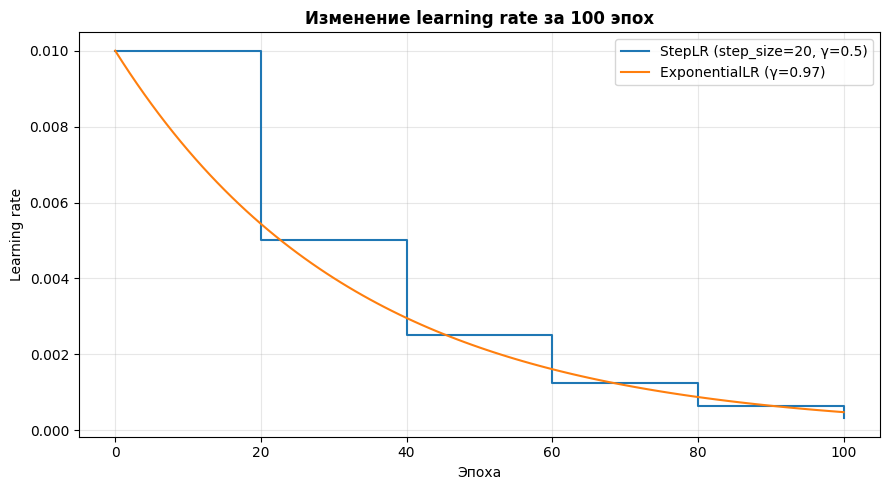

In [11]:
def collect_lr_curve(scheduler_cls, scheduler_kwargs, epochs=EPOCHS, base_lr=LR):
    p = torch.tensor([0.0], requires_grad=True)
    opt = optim.SGD([p], lr=base_lr)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        sched = scheduler_cls(opt, **scheduler_kwargs)
        lrs = [opt.param_groups[0]['lr']]
        for _ in range(epochs):
            sched.step()
            lrs.append(opt.param_groups[0]['lr'])
    return lrs


step_lrs = collect_lr_curve(StepLR, dict(step_size=20, gamma=0.5))
exp_lrs = collect_lr_curve(ExponentialLR, dict(gamma=0.97))

epochs_axis = np.arange(EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_axis, step_lrs, label='StepLR (step_size=20, γ=0.5)', drawstyle='steps-post')
plt.plot(epochs_axis, exp_lrs, label='ExponentialLR (γ=0.97)')
plt.title('Изменение learning rate за 100 эпох', fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Learning rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Регрессия: проверка на сгенерированных данных

In [7]:
def generate_regression(n=NUM_SAMPLES, noise=0.1, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    x = torch.empty(n, 1).uniform_(-3.0, 3.0, generator=g)
    y_clean = torch.sin(2.0 * x) + 0.3 * x
    y = y_clean + noise * torch.randn(n, 1, generator=g)
    return x, y, y_clean


X, Y, Y_clean = generate_regression()
n_train = int(0.8 * NUM_SAMPLES)
perm = torch.randperm(NUM_SAMPLES, generator=torch.Generator().manual_seed(SEED))
train_idx, test_idx = perm[:n_train], perm[n_train:]
X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Train: 409 samples, Test: 103 samples


In [8]:
class MLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / n


def run_experiment(name, optimizer_factory, scheduler_factory, epochs=EPOCHS, seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MLP().to(device)
    optimizer = optimizer_factory(model.parameters())
    scheduler = scheduler_factory(optimizer)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'test_loss': [], 'lr': []}
    print(f"=== {name} ===")
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss = evaluate(model, test_loader, criterion)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        scheduler.step()
        if epoch == 1 or epoch % 20 == 0 or epoch == epochs:
            print(f"  epoch {epoch:3d}  train MSE {train_loss:.4f}  test MSE {test_loss:.4f}  lr {history['lr'][-1]:.5f}")
    return model, history

In [9]:
def step_scheduler(opt):
    return StepLR(opt, step_size=20, gamma=0.5)


OPTIMIZERS = {
    'NesterovSGD': lambda params: NesterovSGD(params, lr=0.05, momentum=0.9),
    'Adam':        lambda params: Adam(params, lr=LR),
    'RMSProp':     lambda params: RMSProp(params, lr=LR),
}

results = {
    name: run_experiment(name, opt_factory, step_scheduler)
    for name, opt_factory in OPTIMIZERS.items()
}

=== NesterovSGD ===
  epoch   1  train MSE 0.5362  test MSE 0.3893  lr 0.05000


  epoch  20  train MSE 0.0864  test MSE 0.0684  lr 0.05000


  epoch  40  train MSE 0.0475  test MSE 0.0517  lr 0.02500


  epoch  60  train MSE 0.0428  test MSE 0.0479  lr 0.01250


  epoch  80  train MSE 0.0393  test MSE 0.0439  lr 0.00625


...

  epoch  20  train MSE 0.0644  test MSE 0.0802  lr 0.01000


  epoch  40  train MSE 0.0382  test MSE 0.0380  lr 0.00500


  epoch  60  train MSE 0.0286  test MSE 0.0395  lr 0.00250


  epoch  80  train MSE 0.0247  test MSE 0.0305  lr 0.00125


  epoch 100  train MSE 0.0227  test MSE 0.0276  lr 0.00063


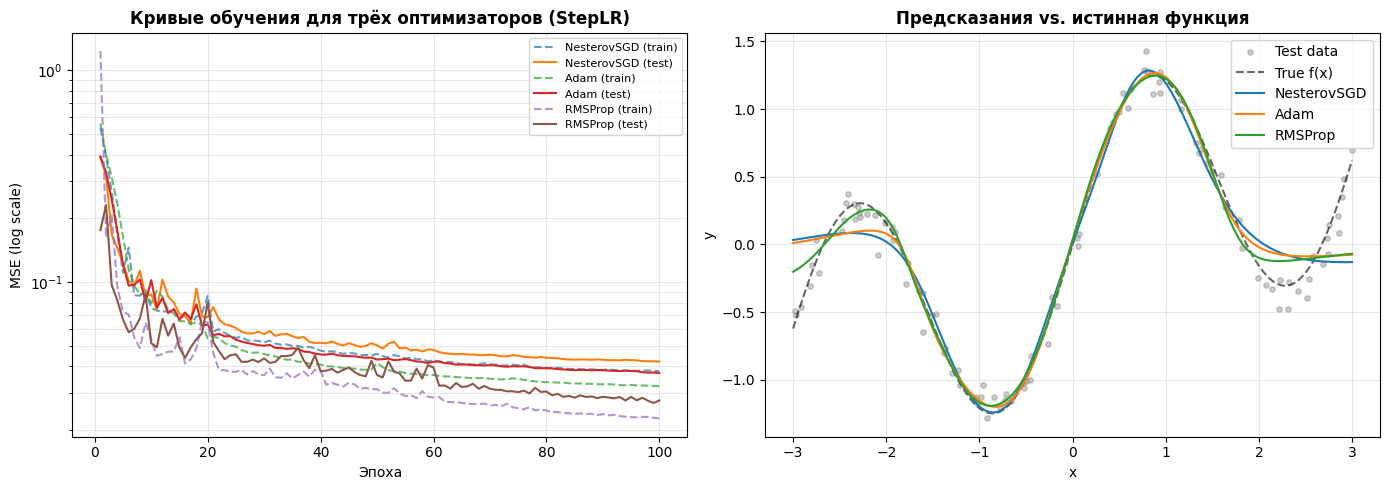

Optimizer      final train MSE   final test MSE   best test MSE
NesterovSGD             0.0380           0.0421          0.0421
Adam                    0.0322           0.0372          0.0372
RMSProp                 0.0227           0.0276          0.0269


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
epochs_axis = np.arange(1, EPOCHS + 1)
for name, (_, h) in results.items():
    ax.plot(epochs_axis, h['train_loss'], label=f'{name} (train)', linestyle='--', alpha=0.7)
    ax.plot(epochs_axis, h['test_loss'], label=f'{name} (test)')
ax.set_yscale('log')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Кривые обучения для трёх оптимизаторов (StepLR)', fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=8)

ax = axes[1]
xs_dense = torch.linspace(-3.0, 3.0, 400).unsqueeze(1).to(device)
ys_true = torch.sin(2.0 * xs_dense) + 0.3 * xs_dense
ax.scatter(X_test.cpu().numpy(), Y_test.cpu().numpy(), s=15, alpha=0.4, label='Test data', color='gray')
ax.plot(xs_dense.cpu().numpy(), ys_true.cpu().numpy(), 'k--', alpha=0.6, label='True f(x)')
for name, (model, _) in results.items():
    model.eval()
    with torch.no_grad():
        ys_pred = model(xs_dense).cpu().numpy()
    ax.plot(xs_dense.cpu().numpy(), ys_pred, label=name)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Предсказания vs. истинная функция', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"{'Optimizer':<12}  {'final train MSE':>16}  {'final test MSE':>15}  {'best test MSE':>14}")
for name, (_, h) in results.items():
    print(f"{name:<12}  {h['train_loss'][-1]:>16.4f}  {h['test_loss'][-1]:>15.4f}  {min(h['test_loss']):>14.4f}")

## Заключение

- **Корректность оптимизаторов доказана** двумя путями: (i) явно выписаны формулы обновления, идентичные PyTorch; (ii) на фиксированной задаче `nn.Linear + MSE` траектории параметров custom-реализаций и эталонных `torch.optim.{SGD(nesterov), Adam, RMSprop}` совпадают пошагово с допуском $10^{-6}$ на 20 шагах. Совпадение всей траектории, а не только финального состояния, исключает случайные совпадения.
- **Корректность шедулеров** проверена аналогично: LR-кривые custom `StepLR` и `ExponentialLR` совпадают с PyTorch на 100 эпохах с машинной точностью.
- **Графики LR за 100 эпох** показывают характерное поведение каждого шедулера: `StepLR(step_size=20, γ=0.5)` — ступенчатое падение в 2 раза каждые 20 эпох (после 100 эпох $0.5^5 \cdot 0.01 \approx 3.1 \cdot 10^{-4}$); `ExponentialLR(γ=0.97)` — плавный геометрический спуск до $0.97^{100} \cdot 0.01 \approx 4.8 \cdot 10^{-4}$. Кривые пересекаются вблизи 50-й эпохи: до этого StepLR держит более высокий LR, после — наоборот.
- **На сгенерированной регрессии** все три оптимизатора с `StepLR(step_size=20, γ=0.5)` уверенно аппроксимируют функцию $\sin(2x) + 0.3x$ на $x \in [-3, 3]$:

  | Оптимизатор   | LR    | final train MSE | final test MSE |
  |---------------|-------|-----------------|----------------|
  | NesterovSGD   | 0.05  | 0.0380          | 0.0421         |
  | Adam          | 0.01  | 0.0322          | 0.0372         |
  | RMSProp       | 0.01  | 0.0227          | 0.0276         |

  Все три значения близки к нижней границе $\sigma^2 = 0.01$ (дисперсия шума в данных). Лидирует RMSProp; Adam отстаёт минимально; NesterovSGD замыкает тройку, но качественно фит ничем не хуже — на правой панели графика все три кривые ложатся на истинную функцию.

- **Замечание о подборе LR.** При одинаковом `lr=0.01` NesterovSGD заметно недообучался: разные оптимизаторы интерпретируют скаляр `lr` по-разному. Adam и RMSProp нормируют шаг на оценку $\sqrt{\mathbb{E}[g^2]}$, поэтому эффективный шаг по параметру близок к `lr` независимо от масштаба градиента. У SGD-с-моментумом шаг — это буквально `lr · g`, и при маленьких градиентах в окрестности минимума он «застаивается». Подъём `lr` до 0.05 компенсирует этот эффект и выравнивает финальное качество.